# MiniHack (`MiniHack-River-v0`) -- replay determinism check

**Data:** `data/sub-test_20260911-095959`

**Command:**
```
python fmri_play.py --subject test --dummy-trigger --curriculum configs/dbp_games/minihack__river.json
```

`MiniHackAdapter.reset()` pins NetHack's own core/display RNG (`env.unwrapped.seed(core=seed, disp=seed, reseed=False)`) before `env.reset(seed=seed)`. This notebook records one reference trajectory (using the recording's `episode_seeds` and action sequence) with the current adapter, then replays those exact seeds + actions `N_REPLAYS` times from fresh environments and checks that `reward`, `terminated`, `truncated`, `blstats`, and `glyphs` all reproduce exactly.

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))
from fmri_gym.adapters.minihack import MiniHackAdapter

N_REPLAYS = 100
DATASET_DIR = os.path.abspath("../data/sub-test_20260911-095959")

pygame-ce 2.5.8 (SDL 2.32.10, Python 3.11.15)


In [2]:
def inspect_dataset(data_dir):
    manifest_path = os.path.join(data_dir, "manifest.json")
    with open(manifest_path, "r") as f:
        manifest = json.load(f)
    game_curriculum = next(p for p in manifest["curriculum"] if p.get("type") == "game")
    game_phase = next(p for p in manifest["phases"] if p.get("type") == "game")
    npz_path = os.path.join(data_dir, game_phase["data_file"])
    data = np.load(npz_path, allow_pickle=True)
    return manifest, data, game_curriculum


manifest, data, curr = inspect_dataset(DATASET_DIR)
game_name = curr["game"]
print(f"Game: {game_name} (Backend: {curr['backend']})")
print(f"Total recorded steps: {len(data['actions'])}")
print(f"Episodes: {len(data['episode_seeds'])}  |  Episode seeds: {data['episode_seeds']}")

Game: MiniHack-River-v0 (Backend: minihack)
Total recorded steps: 317
Episodes: 6  |  Episode seeds: [1002 1003 1004 1005 1006 1007]


In [3]:
def record_reference(game_curr, ref_data):
    actions = ref_data["actions"]
    episode_ids = ref_data["episode_id"]
    episode_seeds = ref_data["episode_seeds"]
    T = len(actions)

    blstats = np.zeros_like(ref_data["blstats"])
    glyphs = np.zeros_like(ref_data["glyphs"])
    rewards = np.zeros(T, dtype=np.float32)
    terminated = np.zeros(T, dtype=bool)
    truncated = np.zeros(T, dtype=bool)

    env = None
    current_ep = -1
    for t in range(T):
        ep_id = int(episode_ids[t])
        if ep_id != current_ep:
            if env is not None:
                env.close()
            env = MiniHackAdapter(game_curr)
            env.reset(int(episode_seeds[ep_id]))
            current_ep = ep_id
        obs, r, term, trunc, info = env.step(int(actions[t]))
        blstats[t] = np.asarray(obs["blstats"])
        glyphs[t] = np.asarray(obs["glyphs"])
        rewards[t], terminated[t], truncated[t] = r, term, trunc
    env.close()

    return {"actions": actions, "rewards": rewards, "terminated": terminated,
            "truncated": truncated, "episode_id": episode_ids, "episode_seeds": episode_seeds,
            "blstats": blstats, "glyphs": glyphs}


reference = record_reference(curr, data)

/Users/arianamondiri/anaconda3/envs/openai-gym/lib/python3.11/site-packages/minihack/base.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
def run_replays(game_curr, ref_data, n_replays):
    ref_actions = ref_data["actions"]
    ref_rewards = ref_data["rewards"]
    ref_terms = ref_data["terminated"]
    ref_truncs = ref_data["truncated"]
    ref_blstats = ref_data["blstats"]
    ref_glyphs = ref_data["glyphs"]
    ref_episode_ids = ref_data["episode_id"]
    ref_episode_seeds = ref_data["episode_seeds"]
    T = len(ref_actions)
    results = []
    env = None

    for r in range(n_replays):
        current_ep = -1
        diverged_step = None
        for t in range(T):
            ep_id = int(ref_episode_ids[t])
            if ep_id != current_ep:
                if env is not None:
                    env.close()
                env = MiniHackAdapter(game_curr)
                env.reset(int(ref_episode_seeds[ep_id]))
                current_ep = ep_id

            obs, reward, term, trunc, info = env.step(int(ref_actions[t]))
            mismatch = (
                not np.isclose(reward, ref_rewards[t], atol=1e-5)
                or bool(term) != bool(ref_terms[t])
                or bool(trunc) != bool(ref_truncs[t])
                or not np.array_equal(np.asarray(obs["blstats"]), ref_blstats[t])
                or not np.array_equal(np.asarray(obs["glyphs"]), ref_glyphs[t])
            )
            if mismatch and diverged_step is None:
                diverged_step = t
                break
        results.append({"replay_idx": r, "exact": diverged_step is None, "diverged_step": diverged_step})

    if env is not None:
        env.close()
    return pd.DataFrame(results)


df = run_replays(curr, reference, N_REPLAYS)
print(f"Dataset ({game_name}): {df['exact'].sum()} / {N_REPLAYS} fully matched.")

Dataset (MiniHack-River-v0): 100 / 100 fully matched.


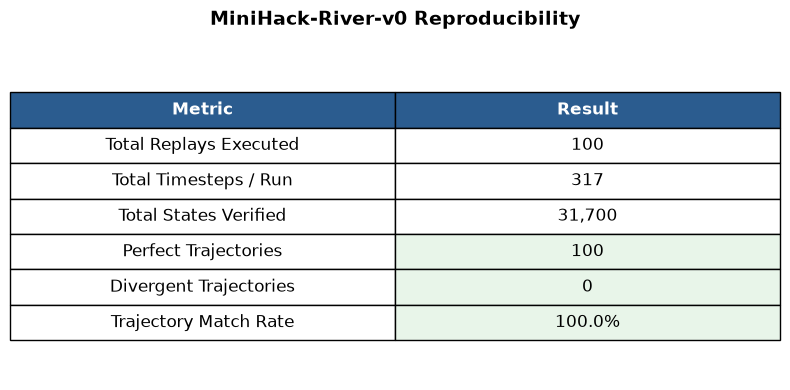

In [5]:
def show_reproducibility_table(df, game_name, total_steps, extra_row=None):
    perfect_runs = df["exact"].sum()
    divergent_runs = len(df) - perfect_runs
    match_rate = (perfect_runs / len(df)) * 100
    total_states = len(df) * total_steps

    table_data = [
        ["Total Replays Executed", f"{len(df)}"],
        ["Total Timesteps / Run", f"{total_steps:,}"],
        ["Total States Verified", f"{total_states:,}"],
        ["Perfect Trajectories", f"{perfect_runs}"],
        ["Divergent Trajectories", f"{divergent_runs}"],
        ["Trajectory Match Rate", f"{match_rate:.1f}%"],
    ]
    if extra_row is not None:
        table_data.append(extra_row)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis("off")
    table = ax.table(cellText=table_data, colLabels=["Metric", "Result"], cellLoc="center",
                      loc="center", colColours=["#2b5c8f", "#2b5c8f"])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.0, 2.0)

    for (row, col), c in table.get_celld().items():
        if row == 0:
            c.set_text_props(color="white", weight="bold")
        elif col == 1:
            metric = table_data[row - 1][0]
            if metric == "Perfect Trajectories":
                c.set_facecolor("#e8f5e9" if perfect_runs == len(df) else "#fff3e0")
            elif metric == "Divergent Trajectories":
                c.set_facecolor("#e8f5e9" if divergent_runs == 0 else "#ffebee")
            elif metric == "Trajectory Match Rate":
                c.set_facecolor("#e8f5e9" if match_rate == 100.0 else "#ffebee")
            elif extra_row is not None and metric == extra_row[0]:
                c.set_facecolor("#e8f5e9" if "None" in extra_row[1] else "#fff3e0")

    plt.title(f"{game_name} Reproducibility", fontsize=14, pad=20, weight="bold")
    plt.tight_layout()
    plt.show()


show_reproducibility_table(df, game_name, len(reference["actions"]))